### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [2]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) in MW
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})

# --- GENERATOR DATA ---
# Col 0: Bus ID | Col 8: Pmax (MW) | Col 9: Pmin (MW)
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 8, 9]].rename(columns={0: 'bus_id', 8: 'Pmax_mw', 9: 'Pmin_mw'})

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 3: Reactance (x) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})

# Calculate Susceptance (B = 1/x) for your DC-OPF B-matrix
branch_data['B_susceptance'] = 1.0 / branch_data['x_reactance']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())

Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  B_susceptance
0       1.0     2.0      0.09990             151.0      10.010010
1       1.0     3.0      0.04240             151.0      23.584906
2       4.0     5.0      0.00798             176.0     125.313283
3       3.0     5.0      0.10800             175.0       9.259259
4       5.0     6.0      0.05400             176.0      18.518519


### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [7]:
import pandas as pd
import numpy as np
import requests
import io
import time
from gridstatus import CAISO

START = "2022-02-03"
END   = "2023-02-03"

# --- 1. CAISO 5-minute system demand ---
iso = CAISO()
load = iso.get_load(
    start=pd.Timestamp(START, tz="US/Pacific"),
    end=pd.Timestamp(END,   tz="US/Pacific"),
)
load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
load["timestamp"] = (pd.to_datetime(load["timestamp"])
                      .dt.tz_convert("US/Pacific")
                      .dt.tz_localize(None))
load["timestamp"] = load["timestamp"].dt.round("5min")
load = (load[["timestamp", "load_mw"]]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .set_index("timestamp"))

# =====================================================================
# 2. ROBUST LAX ASOS: Chunked 5-minute temperature + RH
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=3):
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=LAX&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/Los_Angeles&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    for attempt in range(retries):
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
        elif response.status_code == 503:
            wait_time = 2 ** (attempt + 1)
            print(f"  [!] 503 Server Busy. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        else:
            response.raise_for_status()
            
    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")

print("Fetching weather data in 30-day chunks to prevent IEM server timeouts...")

# Create 30-day intervals to loop through
date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
if pd.Timestamp(END) not in date_chunks:
    date_chunks.append(pd.Timestamp(END))

wx_chunks = []
for i in range(len(date_chunks) - 1):
    s = date_chunks[i]
    e = date_chunks[i+1]
    print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
    
    chunk_df = fetch_asos_chunk(s, e)
    wx_chunks.append(chunk_df)
    time.sleep(1.5)  # Polite pause between chunks

# Combine all the chunks into one DataFrame
wx = pd.concat(wx_chunks, ignore_index=True)
wx = wx.drop_duplicates(subset=["valid"])

# Continue with your exact original data processing
wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
wx["temperature"] = (wx["temp_f"] - 32) * 5/9            

T  = wx["temperature"]
RH = wx["rh_pct"]
wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

wx = wx[["timestamp", "temperature", "humidity"]].dropna()
wx["timestamp"] = wx["timestamp"].dt.round("5min")
wx = (wx.groupby("timestamp").mean().sort_index())

grid = pd.date_range(load.index.min(), load.index.max(), freq="5min")
wx = wx.reindex(grid).interpolate("time", limit=12)   

# --- 3. Merge + sanity check ---
df = load.join(wx, how="inner")
print(f"\nLoad rows:    {len(load):,}")
print(f"Weather rows: {len(wx.dropna()):,}")
print(f"Merged rows:  {len(df):,}   (expect ~105,000 for one year of 5-min)")

100%|██████████| 365/365 [02:39<00:00,  2.29it/s]


Fetching weather data in 30-day chunks to prevent IEM server timeouts...
  -> Pulling chunk: 2022-02-03 to 2022-03-05
  -> Pulling chunk: 2022-03-05 to 2022-04-04
  -> Pulling chunk: 2022-04-04 to 2022-05-04
  [!] 503 Server Busy. Retrying in 2s...
  [!] 503 Server Busy. Retrying in 4s...
  -> Pulling chunk: 2022-05-04 to 2022-06-03
  [!] 503 Server Busy. Retrying in 2s...
  [!] 503 Server Busy. Retrying in 4s...
  -> Pulling chunk: 2022-06-03 to 2022-07-03
  -> Pulling chunk: 2022-07-03 to 2022-08-02
  [!] 503 Server Busy. Retrying in 2s...
  -> Pulling chunk: 2022-08-02 to 2022-09-01
  -> Pulling chunk: 2022-09-01 to 2022-10-01
  -> Pulling chunk: 2022-10-01 to 2022-10-31
  [!] 503 Server Busy. Retrying in 2s...
  [!] 503 Server Busy. Retrying in 4s...
  -> Pulling chunk: 2022-10-31 to 2022-11-30
  [!] 503 Server Busy. Retrying in 2s...
  [!] 503 Server Busy. Retrying in 4s...
  -> Pulling chunk: 2022-11-30 to 2022-12-30
  -> Pulling chunk: 2022-12-30 to 2023-01-29
  -> Pulling chunk

### 3. Demand Distribution and Sample for Scenarios (Dumb Method)

In [22]:
avg_nodal_demand_base = np.average(nodal_demand)

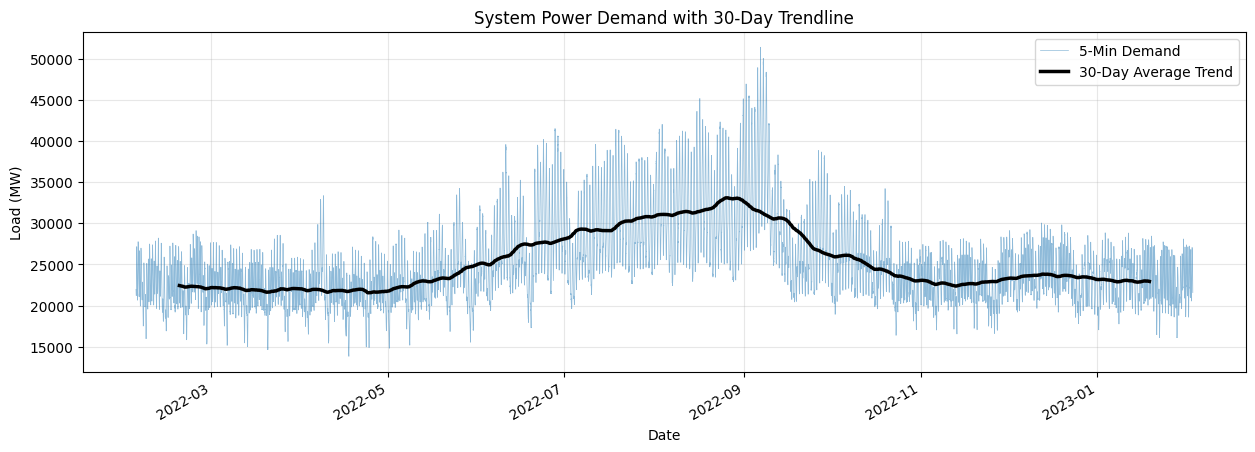

In [33]:
import matplotlib.pyplot as plt

# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()

In [74]:
## Scaling factor generation 
df = df.dropna()
avg_load = np.median(df['load_mw'])
scaling_factor = df['load_mw'] / avg_load
df['scaling_factor'] = scaling_factor

In [75]:
## Identify Generatoy limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 0.95
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()
current_peak = df['scaling_factor'].max()

if current_peak > max_scaling_factor:
    rescale_factor = max_scaling_factor / current_peak
    df['scaling_factor'] = df['scaling_factor'] * rescale_factor

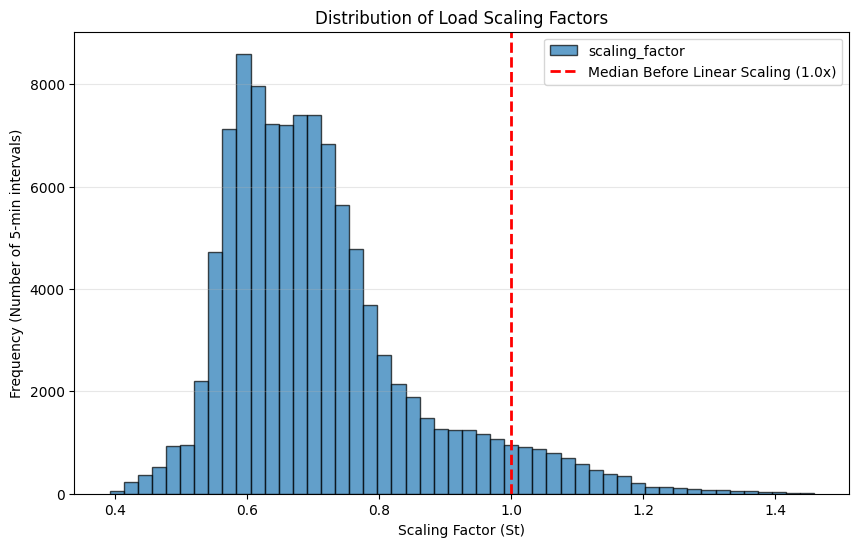

In [78]:
### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

In [70]:
## Scale IEEE 118 test bus today to follow the variance of our data

scaled_nodal_demand = pd.DataFrame(
    np.outer(df['scaling_factor'], nodal_demand['Pd_mw']),
    index=df.index,                 # Your 105,000 timestamps become the rows
    columns=nodal_demand['bus_id']  # Your 118 bus IDs become the columns
)


### 4. Run Two Stage Optimization 

# Phase 2: Predict than Optimizes (Dumb)

### Actually predict demand based on temperature and time of day, year.

In [12]:
import sys, numpy, scipy, statsmodels, pandas
print("Python:", sys.executable)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("pandas:", pandas.__version__)

Python: c:\Users\anble\anaconda3\envs\loadfc\python.exe
numpy: 1.26.4
scipy: 1.17.1
statsmodels: 0.14.6
pandas: 2.3.3


In [13]:
# Block 2: MAFS + ISTD + PGBM pipeline (Sections 3–7 of the paper)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import STL
import warnings; warnings.filterwarnings("ignore")

# =========================================================
# 3. MAFS — Multi-Approach Feature Selection
# =========================================================
candidate_features = ["temperature", "humidity", "month", "day_of_month",
                      "week", "day_of_week", "hour"]
target = "load_mw"

# 3.1 Correlation
corr = df[candidate_features + [target]].corr()[target].drop(target)
print("Pearson correlation with load:\n", corr.round(3))

# 3.3 Random Forest feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(df[candidate_features], df[target])
importance = pd.Series(rf.feature_importances_, index=candidate_features).sort_values(ascending=False)
print("\nRandom Forest feature importance:\n", importance.round(4))

# 3.4 Final selection (mirrors paper's reasoning: drop humidity (weak corr),
# drop month (redundant with week, high corr))
selected = ["temperature", "week", "hour", "day_of_month", "day_of_week"]
print("\nSelected features:", selected)

# =========================================================
# 4. KPSS stationarity test
# =========================================================
def kpss_check(series, name):
    stat, p, _, crit = kpss(series.dropna(), regression="c", nlags=50)
    print(f"{name:12s} KPSS stat={stat:.4f}  p={p:.4f}  crit5%={crit['5%']:.3f}  "
          f"{'STATIONARY' if stat < crit['5%'] else 'NON-STATIONARY'}")

print("\nBefore ISTD:")
kpss_check(df["load_mw"], "load_mw")
kpss_check(df["temperature"], "temperature")

# =========================================================
# 5. ISTD — Iterative Seasonal Trend Decomposition
#    Paper uses daily + weekly seasonality for load, daily only for temp.
#    We use MSTL-style iterative STL (the standard implementation of their idea).
# =========================================================
def istd(series, periods, stl_kwargs=None):
    """Iteratively peel off seasonal components at each period, then the trend."""
    stl_kwargs = stl_kwargs or {}
    resid = series.copy().astype(float)
    seasonals = {}
    for p in periods:
        stl = STL(resid, period=p, robust=True, **stl_kwargs).fit()
        seasonals[p] = stl.seasonal
        resid = resid - stl.seasonal
    # Final trend from the deseasonalized series
    final = STL(resid, period=periods[0], robust=True).fit()
    trend = final.trend
    residual = resid - trend
    return trend, seasonals, residual

# Hourly data: daily period = 24, weekly period = 168
load_trend, load_seasons, load_resid = istd(df["load_mw"], periods=[288, 2016])
temp_trend, temp_seasons, temp_resid = istd(df["temperature"], periods=[288])

# Normalize the residuals (final stationary inputs to PGBM)
load_scaler = StandardScaler()
temp_scaler = StandardScaler()
df["load_stationary"] = load_scaler.fit_transform(load_resid.values.reshape(-1, 1)).ravel()
df["temp_stationary"] = temp_scaler.fit_transform(temp_resid.values.reshape(-1, 1)).ravel()

print("\nAfter ISTD:")
kpss_check(df["load_stationary"], "load_stat")
kpss_check(df["temp_stationary"], "temp_stat")

# =========================================================
# 6. PGBM — Probabilistic Gradient Boosting Model
#    Gradient boosting with quantile loss at alpha = 0.025, 0.5, 0.975
#    Paper's hyperparameters from Table 4.
# =========================================================

# Replace temperature with its stationary version; target is stationary load
df["temperature"] = df["temp_stationary"]

# Lag features on the STATIONARY target (paper uses 6 lags)
N_LAGS = 6
for k in range(1, N_LAGS + 1):
    df[f"lag_{k}"] = df["load_stationary"].shift(k)

feature_cols = selected + [f"lag_{k}" for k in range(1, N_LAGS + 1)]
data = df.dropna().copy()

X = data[feature_cols].values
y = data["load_stationary"].values

# 80/20 time-ordered split
split = int(0.8 * len(data))
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]
idx_te = data.index[split:]

# Paper's Table 4 hyperparameters
gbr_params = dict(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.1,
    min_samples_leaf=20,
    min_samples_split=3,
    loss="quantile",
    random_state=0,
)

models = {}
for alpha in [0.025, 0.5, 0.975]:
    m = GradientBoostingRegressor(alpha=alpha, **gbr_params)
    m.fit(X_tr, y_tr)
    models[alpha] = m

pred_lo  = models[0.025].predict(X_te)
pred_med = models[0.5  ].predict(X_te)
pred_hi  = models[0.975].predict(X_te)

# =========================================================
# 7. Seasonal-Trend Reconstruction (STR) — inverse of ISTD
# =========================================================
def reconstruct(pred_stationary, test_index, scaler, trend, seasonals):
    unscaled = scaler.inverse_transform(pred_stationary.reshape(-1, 1)).ravel()
    s = pd.Series(unscaled, index=test_index)
    s = s + trend.reindex(test_index)
    for comp in seasonals.values():
        s = s + comp.reindex(test_index)
    return s

actual    = df["load_mw"].reindex(idx_te)
pred_mw   = reconstruct(pred_med, idx_te, load_scaler, load_trend, load_seasons)
lower_mw  = reconstruct(pred_lo,  idx_te, load_scaler, load_trend, load_seasons)
upper_mw  = reconstruct(pred_hi,  idx_te, load_scaler, load_trend, load_seasons)

# =========================================================
# Metrics (paper reports MAE, MSE, RMSE, R2)
# =========================================================
mae  = mean_absolute_error(actual, pred_mw)
mse  = mean_squared_error(actual, pred_mw)
rmse = np.sqrt(mse)
r2   = r2_score(actual, pred_mw)
print(f"\nTest metrics — MAE={mae:.3f}  MSE={mse:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}")

# Plot a 1-day slice with 95% CI (mirrors Fig. 15)
one_day = idx_te[:24]
plt.figure(figsize=(11, 4))
plt.plot(one_day, actual.loc[one_day],   label="Actual",    color="crimson")
plt.plot(one_day, pred_mw.loc[one_day],  label="Predicted", color="navy")
plt.fill_between(one_day, lower_mw.loc[one_day], upper_mw.loc[one_day],
                 alpha=0.25, color="navy", label="95% CI")
plt.title("PGBM one-day-ahead forecast with uncertainty")
plt.ylabel("Load (MW)"); plt.legend(); plt.tight_layout(); plt.show()

KeyError: "['month', 'day_of_month', 'week', 'day_of_week', 'hour'] not in index"